## Predicting Algorithms

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pos_fraction = np.linspace(0.00, 1.00, 1000)

In [3]:
gini = 1 - pos_fraction**2 - (1-pos_fraction)**2

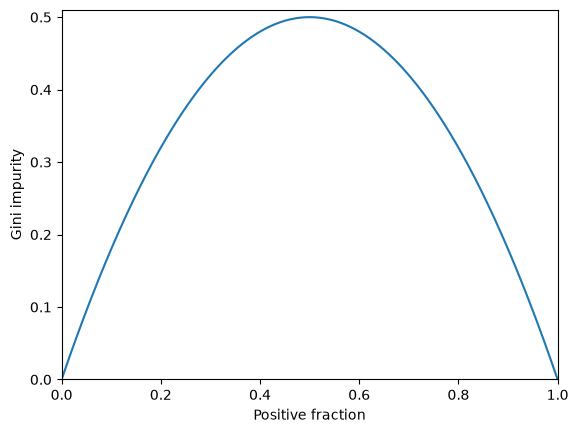

In [5]:
plt.plot(pos_fraction, gini)
plt.xlim(0, 1)
plt.ylim(0, 0.51)
plt.xlabel('Positive fraction')
plt.ylabel('Gini impurity')
plt.show()

In [8]:
def gini_impurity(labels):
    # When the set is empty, it is also pure
    if len(labels) == 0:
        return 0
    # Count the occurrences of each label
    counts = np.unique(labels, return_counts=True)[1]
    fractions = counts / float(len(labels))
    return 1 - np.sum(fractions ** 2)

In [9]:
print(f'{gini_impurity([1,1,0,0,1]):.2f}')

0.48


### Information Gain

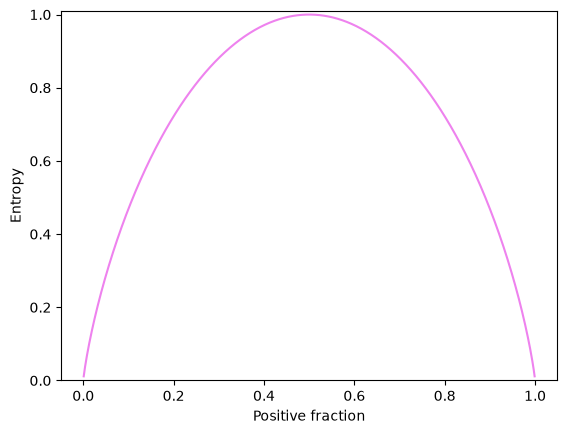

In [10]:
pos_fraction = np.linspace(0.001, 0.999, 1000)
ent = - (pos_fraction * np.log2(pos_fraction) + (1 - pos_fraction) * np.log2(1 - pos_fraction))

plt.plot(pos_fraction, ent, color="violet")
plt.xlabel('Positive fraction')
plt.ylabel('Entropy')
plt.ylim(0, 1.01)
plt.show()

In [11]:
def entropy(labels):
    if len(labels) == 0:
        return 0
    counts = np.unique(labels, return_counts=True)[1]
    fractions = counts / float(len(labels))
    return - np.sum(fractions * np.log2(fractions))

In [13]:
print(f'{entropy([1, 1, 0, 1, 0, 0]):.4f}')
print(f'{entropy([1, 1, 0, 1, 0]):.4f}')

1.0000
0.9710


In [12]:
criterion_function = {'gini': gini_impurity,'entropy': entropy}
def weighted_impurity(groups, criterion='gini'):
    """
    Calculate weighted impurity of children after a split
    @param groups: list of children, and a child consists a
    list of class labels
    @param criterion: metric to measure the quality of a split,
    'gini' for Gini impurity or 'entropy' for
    information gain
    @return: float, weighted impurity
    """
    total = sum(len(group) for group in groups)
    weighted_sum = 0.0
    for group in groups:
        weighted_sum += len(group) / float(total) * criterion_function[criterion](group)
    return weighted_sum

In [13]:
def split_node(X, y, index, value):
    x_index = X[:, index]
    # if this feature is numerical
    if X[0, index].dtype.kind in ['i', 'f']:
        mask = x_index >= value
    # if this feature is categorical
    else:
        mask = x_index == value
    # split into left and right child
    left = [X[~mask, :], y[~mask]]
    right = [X[mask, :], y[mask]]
    return left, right

In [14]:
def get_best_split(X, y, criterion):
    best_index, best_value, best_score, children = None, None, 1, None
    for index in range(len(X[0])):
        for value in np.sort(np.unique(X[:, index])):
            groups = split_node(X, y, index, value)
            impurity = weighted_impurity([groups[0][1], groups[1][1]], criterion)
            if impurity < best_score:
                best_index, best_value, best_score, children = index, value, impurity, groups
    return {
        'index': best_index, 
        'value': best_value,
        'children': children
        }

In [15]:
def get_leaf(labels):
    # Return the most common label in the leaf
    return np.bincount(labels).argmax()

In [16]:
def split(node, max_depth, min_size, depth, criterion):
    left, right = node['children']
    del (node['children'])
    if left[1].size == 0:
        node['right'] = get_leaf(right[1])
        return
    if right[1].size == 0:
        node['left'] = get_leaf(left[1])
        return
    # Check if the current depth exceeds the maximal depth
    if depth >= max_depth:
        node['left'], node['right'] = get_leaf(left[1]), get_leaf(right[1])
        return
    # Check if the left child has enough samples
    if left[1].size <= min_size:
        node['left'] = get_leaf(left[1])
    else:
    # It has enough samples, we further split it
        result = get_best_split(left[0], left[1], criterion)
        result_left, result_right = result['children']
        if result_left[1].size == 0:
            node['left'] = get_leaf(result_right[1])
        elif result_right[1].size == 0:
            node['left'] = get_leaf(result_left[1])
        else:
            node['left'] = result
            split(node['left'], max_depth, min_size, depth + 1, criterion)
    # Check if the right child has enough samples
    if right[1].size <= min_size:
        node['right'] = get_leaf(right[1])
    else:
        # It has enough samples, we further split it
        result = get_best_split(right[0], right[1], criterion)
        result_left, result_right = result['children']
        if result_left[1].size == 0:
            node['right'] = get_leaf(result_right[1])
        elif result_right[1].size == 0:
            node['right'] = get_leaf(result_left[1])
        else:
            node['right'] = result
            split(node['right'], max_depth, min_size, depth + 1, criterion)

In [17]:
def train_tree(
    X_train, 
    y_train, 
    max_depth, 
    min_size, criterion='gini'):
    X = np.array(X_train)
    y = np.array(y_train)
    root = get_best_split(X, y, criterion)
    split(root, max_depth, min_size, 1, criterion)
    return root

### Now let's define train example

In [18]:
X_train = [['tech', 'professional'],
        ['fashion', 'student'],
        ['fashion', 'professional'],
        ['sports', 'student'],
        ['tech', 'student'],
        ['tech', 'retired'],
        ['sports', 'professional']]
y_train = [1, 0, 0, 0, 1, 0, 1]
tree = train_tree(X_train, y_train, 2, 2)

In [24]:
CONDITION = {'numerical': {'yes': '>=', 'no': '<'}, 'categorical': {'yes': 'is', 'no': 'is not'}}

def visualize_tree(node, depth=0):
    if isinstance(node, dict):
        if node['value'].dtype.kind in ['i', 'f']:
            condition = CONDITION['numerical']
        else:
            condition = CONDITION['categorical']
        print('{}|- X{} {} {}'.format(depth * ' ', node['index'] + 1, condition['no'], node['value']))
        if 'left' in node:
            visualize_tree(node['left'], depth + 1)
        print('{}|- X{} {} {}'.format(depth * ' ', node['index'] + 1, condition['yes'], node['value']))
        if 'right' in node:
            visualize_tree(node['right'], depth + 1)
    else:
        print(f"{depth * ' '}[{node}]")

In [25]:
visualize_tree(tree)

|- X1 is not fashion
 |- X2 is not professional
  [0]
 |- X2 is professional
  [1]
|- X1 is fashion
 [0]


In [26]:
X_train_n = [[6, 7],
            [2, 4],
            [7, 2],
            [3, 6],
            [4, 7],
            [5, 2],
            [1, 6],
            [2, 0],
            [6, 3],
            [4, 1]]
y_train_n = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
tree = train_tree(X_train_n, y_train_n, 2, 2)
visualize_tree(tree)

|- X2 < 4
 |- X1 < 7
  [1]
 |- X1 >= 7
  [0]
|- X2 >= 4
 |- X1 < 2
  [1]
 |- X1 >= 2
  [0]


## Implementing a decision tree with scikit-learn

In [27]:
from sklearn.tree import DecisionTreeClassifier
tree_sk = DecisionTreeClassifier(criterion='gini', max_depth=2, min_samples_split=2)

tree_sk.fit(X_train_n, y_train_n)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

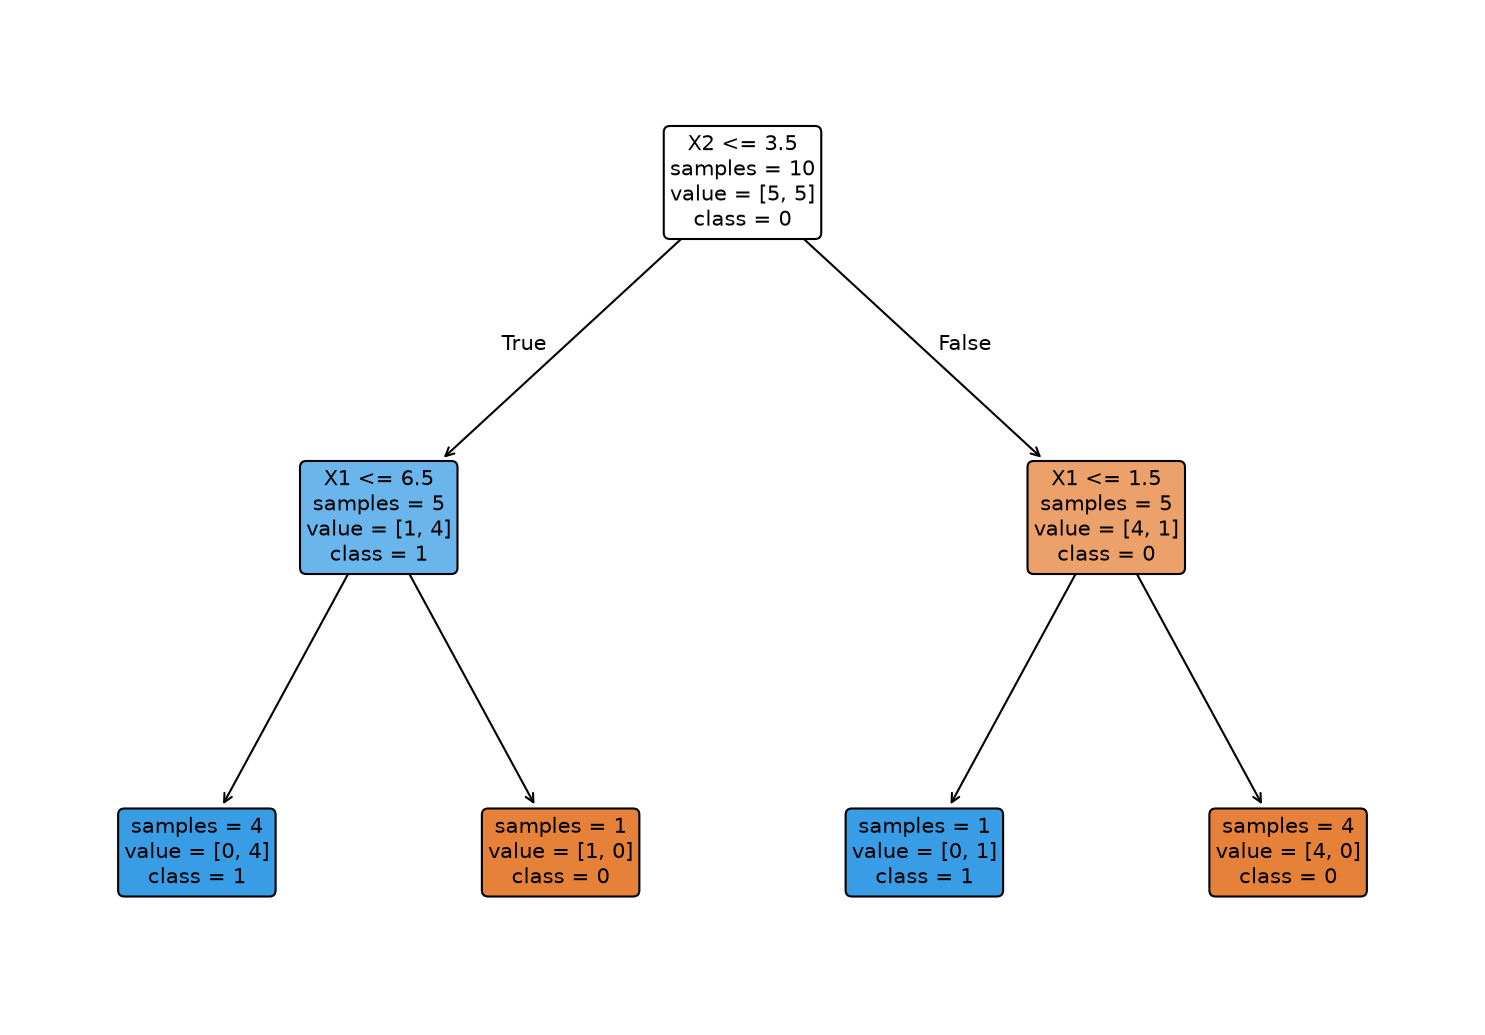

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7), dpi=150)

plot_tree(
    tree_sk,
    feature_names=['X1', 'X2'],
    class_names=['0', '1'],
    impurity=False,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.tight_layout()
# plt.savefig("tree.png", dpi=300, bbox_inches="tight")
aplt.show()

## Click-Through Rate Prediction 

In [35]:
import pandas as pd
df = pd.read_csv("./data/train_300k.csv")

In [36]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


In [41]:
df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'],
      dtype='str')

In [40]:
Y = df['click'].values

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [42]:
X = df.drop(columns=['click', 'id', 'hour', 'device_ip', 'device_id' ]).values
X.shape

(300000, 19)

In [43]:
n_rows = X.shape[0]

n_train = int(n_rows * 0.9)
X_train, X_test = X[:n_train], X[n_train:]
Y_train, Y_test = Y[:n_train], Y[n_train:]

In [44]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')

In [46]:
X_train_encoded = encoder.fit_transform(X_train)
print(X_train_encoded.shape)
X_train_encoded[0]

(270000, 8204)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19 stored elements and shape (1, 8204)>

In [47]:
print(X_train_encoded[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19 stored elements and shape (1, 8204)>
  Coords	Values
  (0, 2)	1.0
  (0, 6)	1.0
  (0, 188)	1.0
  (0, 2608)	1.0
  (0, 2679)	1.0
  (0, 3771)	1.0
  (0, 3885)	1.0
  (0, 3929)	1.0
  (0, 4879)	1.0
  (0, 7315)	1.0
  (0, 7319)	1.0
  (0, 7475)	1.0
  (0, 7824)	1.0
  (0, 7828)	1.0
  (0, 7869)	1.0
  (0, 7977)	1.0
  (0, 7982)	1.0
  (0, 8021)	1.0
  (0, 8189)	1.0


In [48]:
X_test_encoded = encoder.transform(X_test)

In [49]:
from sklearn.tree import DecisionTreeClassifier
parameters = {'max_depth': [3, 10, None]}

In [ ]:
decision_tree = DecisionTreeClassifier(criterion='gini', min_samples_split=30)